# Data Foundation and Temporal Design

## Executive summary

This notebook establishes the analytical foundation for the Version 2
Workforce Intelligence Platform:

- 10,000 synthetic employee histories are generated and validated.
- A monthly attrition hazard removes the Version 1 all-leaders-active artifact.
- Three nonoverlapping twelve-month prediction windows support temporal
  backtesting.
- The 2025 snapshot is reserved until the final policy is frozen.
- A target-free feature policy reduces redundancy before model comparison.

**Data notice:** every person, event, outcome, and financial value in this
project is synthetic. Results demonstrate an analytical workflow, not facts
about a real employer.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "config" / "portfolio_notebooks.yaml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook inside the project repository.")


PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

## Version 2 data integrity

The generator must pass hierarchy, censoring, event-reconciliation, outcome,
signal, and leakage checks before any modeling dataset is constructed.

In [2]:
v2_checks = pd.read_csv(
    PROCESSED / "v2_validation" / "validation_summary.csv"
)

integrity_summary = pd.DataFrame(
    {
        "validation_checks": [len(v2_checks)],
        "passed": [v2_checks["status"].eq("PASS").sum()],
        "failed": [v2_checks["status"].ne("PASS").sum()],
    }
)
display(integrity_summary)

,validation_checks,passed,failed
0,19,19,0


In [3]:
comparison = pd.read_csv(
    PROCESSED / "v2_validation" / "v1_v2_comparison.csv"
)
key_metrics = [
    "Cumulative attrition rate",
    "Leadership terminations",
    "Snapshot eligible employees",
    "Snapshot positive cases",
    "Snapshot positive rate",
    "Manager reassignments after exit",
]
display(
    comparison.loc[
        comparison["metric"].isin(key_metrics),
        ["metric", "version_1", "version_2", "absolute_change"],
    ].round(4)
)

,metric,version_1,version_2,absolute_change
2,Cumulative attrition rate,0.1713,0.2591,0.0878
4,Leadership terminations,0.0000,276.0000,276.0000
5,Snapshot eligible employees,7386.0000,6745.0000,-641.0000
6,Snapshot positive cases,627.0000,803.0000,176.0000
7,Snapshot positive rate,0.0849,0.1191,0.0342
8,Manager reassignments after exit,0.0000,1913.0000,1913.0000


Version 2 allows team-manager exits, reassigns affected reports, and censors
all post-employment history. The cumulative termination rate describes the
complete simulation; it is not the same as the forward twelve-month modeling
target.

## Temporal prediction design

Each row represents an employee who is active on a snapshot date. Its target
equals one only when termination occurs after that snapshot and no later than
the prediction-end date.

In [4]:
snapshots = pd.read_csv(
    PROCESSED
    / "temporal_dataset_validation"
    / "snapshot_summary.csv",
    parse_dates=["snapshot_date", "prediction_end_date"],
)
display(
    snapshots.assign(
        positive_rate=snapshots["positive_rate"].map(
            lambda value: f"{value:.1%}"
        )
    )
)

,snapshot_sequence,snapshot_date,prediction_end_date,eligible_employees,positive_cases,positive_rate,negative_cases
0,1,2023-06-30,2024-06-30,4303,414,9.6%,3889
1,2,2024-06-30,2025-06-30,5625,586,10.4%,5039
2,3,2025-06-30,2026-06-30,6745,803,11.9%,5942


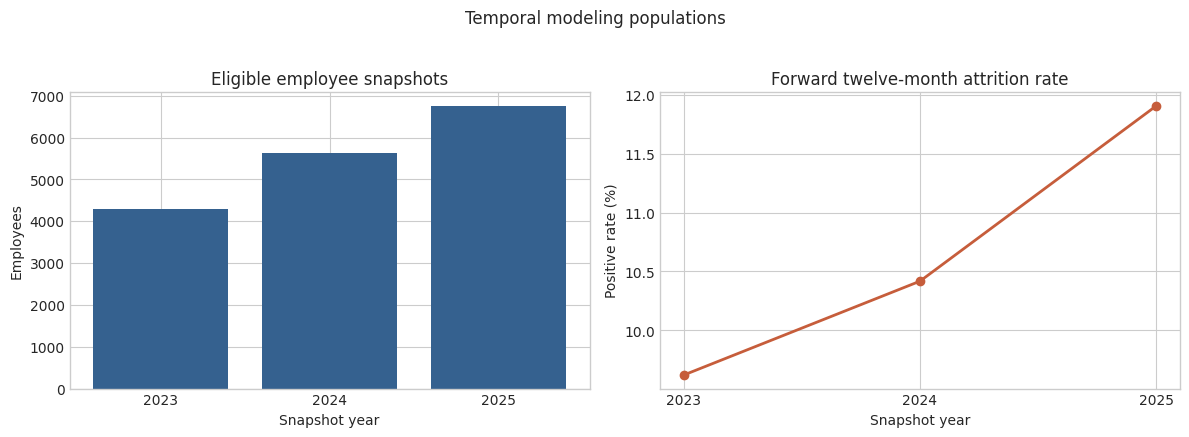

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].bar(
    snapshots["snapshot_date"].dt.strftime("%Y"),
    snapshots["eligible_employees"],
    color="#35618f",
)
axes[0].set(
    title="Eligible employee snapshots",
    xlabel="Snapshot year",
    ylabel="Employees",
)

axes[1].plot(
    snapshots["snapshot_date"].dt.strftime("%Y"),
    snapshots["positive_rate"] * 100,
    marker="o",
    linewidth=2,
    color="#c65d3b",
)
axes[1].set(
    title="Forward twelve-month attrition rate",
    xlabel="Snapshot year",
    ylabel="Positive rate (%)",
)

figure.suptitle("Temporal modeling populations", y=1.03)
figure.tight_layout()
plt.show()

In [6]:
splits = pd.read_csv(PROCESSED / "model_split_summary.csv")
display(
    splits[
        [
            "primary_split",
            "snapshot_date",
            "prediction_end_date",
            "rows",
            "target_status",
            "positive_cases",
            "positive_rate",
        ]
    ]
)

,primary_split,snapshot_date,prediction_end_date,rows,target_status,positive_cases,positive_rate
0,train,2023-06-30,2024-06-30,4206,AVAILABLE_FOR_DEVELOPMENT,414,0.098431
1,validation,2024-06-30,2025-06-30,5521,AVAILABLE_FOR_DEVELOPMENT,586,0.106140
2,test,2025-06-30,2026-06-30,6641,RESERVED_NOT_ACCESSED,RESERVED,RESERVED


The split artifact deliberately redacts the reserved test outcomes. Repeated
employees remain together in employee-grouped robustness folds, preventing
the same person from appearing on both sides of a grouped evaluation.

## Feature policy and leakage controls

Features use only records available on or before each snapshot. Direct
employment status and termination fields are excluded. Reference-category
encoding removes dummy-variable traps, while redundant measurements are
removed before model selection.

In [7]:
feature_checks = pd.read_csv(
    PROCESSED / "feature_policy_validation.csv"
)
vif = pd.read_csv(PROCESSED / "vif_diagnostics.csv")
condition = pd.read_csv(PROCESSED / "condition_number_diagnostics.csv")

feature_summary = pd.DataFrame(
    {
        "policy_checks": [len(feature_checks)],
        "checks_passed": [feature_checks["status"].eq("PASS").sum()],
        "maximum_vif": [vif["vif"].max()],
        "condition_number": [
            condition.loc[
                condition["metric"].eq("Condition number"),
                "value",
            ].iloc[0]
        ],
    }
)
display(feature_summary.round(3))

,policy_checks,checks_passed,maximum_vif,condition_number
0,13,13,3.95,5.290241030429102


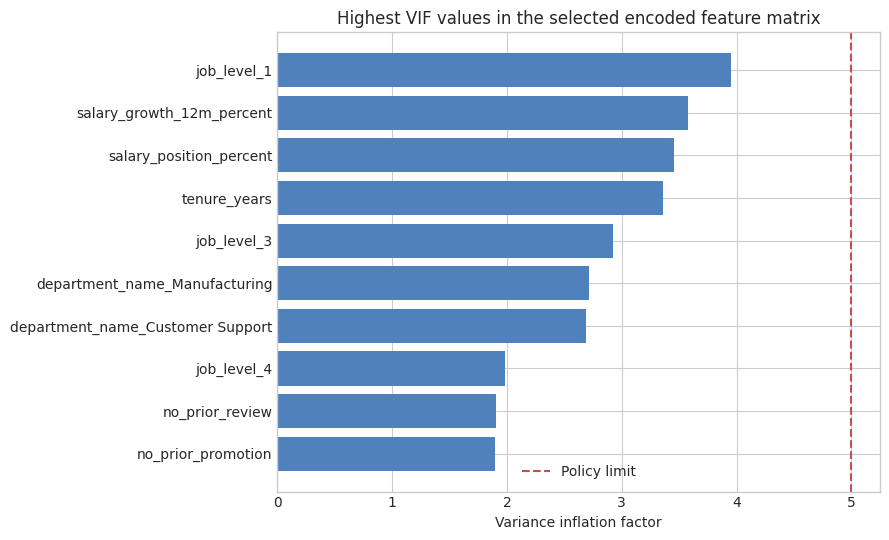

In [8]:
top_vif = vif.head(10).sort_values("vif")

plt.figure(figsize=(9, 5.5))
plt.barh(top_vif["encoded_feature"], top_vif["vif"], color="#4f81bd")
plt.axvline(5.0, color="#c44e52", linestyle="--", label="Policy limit")
plt.xlabel("Variance inflation factor")
plt.title("Highest VIF values in the selected encoded feature matrix")
plt.legend()
plt.tight_layout()
plt.show()

## Portfolio takeaways

1. Version 2 produces plausible but intentionally imperfect observable signal.
2. Historical labels are fully observable and nonoverlapping.
3. Current active employees have unknown future outcomes and are kept in a
   separate scoring population.
4. The feature matrix is full rank and below committed VIF and condition-number
   limits.
5. The reserved 2025 target is not used during feature or model development.

These controls make later model comparisons credible, but they do not make
synthetic associations causal or transferable to a real employer.

### Portfolio navigation

Next: [Model Development and Final Evaluation](02_model_development_and_final_evaluation.ipynb)